<!-- File automatically generated using DocOnce (https://github.com/doconce/doconce/):
doconce format ipynb introduction_gpc_v2.do.txt --encoding=utf-8 --ipynb_admon=hrule --ipynb_disable_mpl_inline --ipynb_cite=latex-plain -->

<!-- File automatically generated using DocOnce (https://github.com/doconce/doconce/):
doconce format ipynb introduction_gpc_v2.do.txt --encoding=utf-8 --ipynb_admon=hrule --ipynb_disable_mpl_inline --ipynb_cite=latex-plain

# An introduction to polynomial chaos expansions with chaospy

**Vinzenz Gregor Eck**, Expert Analytics, Oslo  
**Jacob Sturdy**, Department of Structural Engineering, NTNU   
**Leif Rune Hellevik**, Department of Structural Engineering, NTNU  
Date: Sep 25, 2018  
Date: **January 23, 2026** Revised by LRH  
Date: **May 13, 2026** Revised by LRH

### Setup

In [1]:
# --- cell: install_chaospy ---
# @title Install chaospy (Colab-friendly)

try:
    import chaospy as cp
    import numpoly
    import numpy as np
    print("chaospy er allerede installert.")
except ImportError:
    # Installer chaospy fra PyPI. Dette drar inn numpoly automatisk.
    %pip install chaospy==4.3.21 --no-cache-dir
    import chaospy as cp
    import numpoly
    import numpy as np

print("numpy  :", np.__version__)
print("numpoly:", numpoly.__version__)
print("chaospy:", cp.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 16.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.5/254.5 kB 309.2 MB/s eta 0:00:00
  Created wheel for numpoly: filename=numpoly-1.3.9-cp312-cp312-linux_x86_64.whl size=1109774 sha256=068d81b288eb895f8715fcb4f9bc907d805ef1c8f7f5c520af3f1106cdcb1f8c
  Stored in directory: /tmp/pip-ephem-wheel-cache-9naxsfws/wheels/3b/b9/a0/aaf362cdd052e668c38a5b2270f4fc8f613c254dce679a00ed
Successfully built numpoly
numpy  : 2.0.2
numpoly: 1.3.9
chaospy: 4.3.21


In [2]:
# --- cell: repo_setup ---
# @title Repo sync and environment setup

import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
REMOTE = "https://github.com/lrhgit/uqsa2025.git"
REPO_PATH_COLAB = Path("/content/uqsa2025")

if IN_COLAB:
    if not REPO_PATH_COLAB.exists():
        print("Cloning repository...")
        subprocess.run(
            ["git", "clone", REMOTE, str(REPO_PATH_COLAB)],
            check=True
        )
    else:
        print("Updating existing repository...")
        subprocess.run(
            ["git", "-C", str(REPO_PATH_COLAB), "pull"],
            check=True
        )
    os.chdir(REPO_PATH_COLAB)

# --- Find repo root (works locally + in Colab) ---
cwd = Path.cwd().resolve()
repo_root = next(
    (p for p in [cwd] + list(cwd.parents) if (p / ".git").exists()),
    cwd
)

PY_SRC = repo_root / "python_source"
if PY_SRC.exists() and str(PY_SRC) not in sys.path:
    sys.path.insert(0, str(PY_SRC))

print("CWD:", Path.cwd())
print("repo_root:", repo_root)
print("python_source exists:", PY_SRC.exists())
print("python_source in sys.path:", str(PY_SRC) in sys.path)

Cloning repository...
CWD: /content/uqsa2025
repo_root: /content/uqsa2025
python_source exists: True
python_source in sys.path: True


In [3]:
# --- cell: layout_and_numpy_patch ---
# @title Layout fix, imports, and NumPy compatibility patch

import warnings
warnings.filterwarnings("ignore")

from IPython.display import HTML

HTML("""
<style>
div.cell.code_cell, div.output {
    max-width: 100% !important;
}
</style>
""")

import numpy as np
import matplotlib.pyplot as plt
import chaospy as cp
import numpoly
import pandas as pd


# Pretty-print helpers (used across notebooks)
from pretty_printing import section_title, pretty_table, pretty_print_sobol_mc


# --- NumPy reshape compatibility patch for numpoly ---
_old_reshape = np.reshape

def _reshape_compat(a, *args, **kwargs):
    newshape = None
    if "newshape" in kwargs:
        newshape = kwargs.pop("newshape")
    if "shape" in kwargs and newshape is None:
        newshape = kwargs.pop("shape")
    if newshape is not None:
        return _old_reshape(a, newshape, *args, **kwargs)
    return _old_reshape(a, *args, **kwargs)

np.reshape = _reshape_compat
print("✓ numpy.reshape patched for numpoly compatibility")

✓ numpy.reshape patched for numpoly compatibility


In [4]:
# @title
# imports for gpc
import math

# Introduction
<div id="sec:introduction"></div>

This notebook introduces uncertainty quantification and sensitivity analysis (UQSA) using polynomial chaos expansions (PCE) with the Python package `chaospy`.

`chaospy` provides practical tools for defining random variables, constructing joint distributions, generating samples, and building non-intrusive polynomial chaos expansions with only a few lines of code. A comprehensive [user guide](https://chaospy.readthedocs.io/en/master/user_guide/index.html) with tutorials and examples is available for readers who want to explore the package in more depth.

Since the same package also supports flexible sampling strategies, it is used in parts of the Monte Carlo workflow as well, allowing a more consistent comparison between the two approaches.

The following sections introduce the main ideas behind polynomial chaos and provide a practical step-by-step guide to applying `chaospy`.

# Polynomial chaos
<div id="sec:polynomialChaos"></div>


## The concept of polynomial chaos
The main idea of polynomial chaos is to approximate the stochastic response of a model with uncertain inputs by a polynomial expansion in the random input variables.

For simplicity, consider a model response that depends on random variables $\mathbf{Z}$ as well as non-random parameters such as spatial coordinates $x$ or time $t$:

$$
Y = y(x, t, \mathbf{Z})
$$

We seek a polynomial approximation of this stochastic model response:

<!-- Equation labels as ordinary links -->
<div id="_auto2"></div>

$$
Y = y(x, t, \mathbf{Z}) \approx y_{N} = \sum_{i=1}^{P} v_i(x, t)\,\Phi_i(\mathbf{Z}),
$$

where $v_i$ are expansion coefficients that depend only on the deterministic parameters, while $\Phi_i$ are orthogonal polynomial basis functions defined in terms of the random inputs $\mathbf{Z}$.

Once the polynomial expansion has been constructed, statistical quantities such as expectation, variance, prediction intervals, and sensitivity indices can be computed analytically from the approximation.

Because polynomial chaos often requires far fewer model evaluations than Monte Carlo methods to achieve comparable accuracy, it is particularly attractive for computationally expensive models.


## Applicability

Polynomial chaos can be applied in a wide variety of settings. A fundamental requirement for convergence is that the model response is square integrable with respect to the inner product induced by the chosen probability measure. In practical terms, this means that the response must have finite variance.

However, applicability does not guarantee rapid convergence. The convergence rate depends strongly on the smoothness of the model response with respect to the uncertain inputs: smooth responses are typically approximated efficiently, whereas non-smooth behavior or discontinuities may require substantially higher polynomial orders or alternative formulations.

Polynomial chaos can still be applied in the presence of discontinuities, but in such cases it may be advantageous to reformulate the problem or consider alternative approximation strategies (see Feinberg, Eck and Langtangen, 2016).

## Orthogonal polynomials

As discussed above, the polynomial chaos expansion represents the model response as a sum of basis polynomials in the uncertain input variables $\mathbf{Z}$.

The use of *orthogonal* basis polynomials improves both numerical efficiency and the analytical extraction of uncertainty statistics and sensitivity measures.

For polynomial chaos, orthogonality is defined with respect to the probability distribution $f_{\mathbf Z}(\mathbf z)$ of the uncertain inputs. Two basis polynomials are orthogonal if the expected value of their product is zero:

$$
\langle \Phi_i,\Phi_j \rangle
=
\mathbb{E}[\Phi_i(\mathbf{Z})\Phi_j(\mathbf{Z})]
=
\int_{\Omega}\Phi_i(\mathbf{z})\Phi_j(\mathbf{z})f_{\mathbf Z}(\mathbf{z})\,d\mathbf z
=
h_j\delta_{ij}.
$$

where $h_j$ is a normalization constant and $\delta_{ij}$ is the Kronecker delta.

Because orthogonality is defined with respect to the input probability distribution, different polynomial families are naturally associated with different distributions. For example:

- Gaussian input → Hermite polynomials
- Uniform input → Legendre polynomials
- Gamma input → Laguerre polynomials
- Beta input → Jacobi polynomials

This orthogonality property makes polynomial chaos particularly convenient, since moments and sensitivity indices can be computed directly from the expansion coefficients. In practice, `chaospy` constructs suitable polynomial bases automatically from the specified input distributions.

## Expansion coefficients

There are two common non-intrusive ways to determine the coefficients in a polynomial chaos expansion: regression and pseudo-spectral projection.

### Regression

In the regression approach, the model is evaluated at a set of sampled input points $\{\mathbf{z}^{(s)}\}_{s=1}^{N}.$

For each sample, the corresponding model response is computed:

$$
y^{(s)} = y(\mathbf{z}^{(s)}).
$$

The polynomial chaos approximation

$$
y_N(\mathbf{Z}) = \sum_{i=0}^{P} v_i \Phi_i(\mathbf{Z})
$$

is then fitted to these input–output pairs by solving for the coefficients $v_i$.

In matrix form, this becomes:

$$
\begin{bmatrix}
\Phi_0(\mathbf{z}^{(1)}) & \cdots & \Phi_P(\mathbf{z}^{(1)}) \\
\vdots & & \vdots \\
\Phi_0(\mathbf{z}^{(N)}) & \cdots & \Phi_P(\mathbf{z}^{(N)})
\end{bmatrix}
\begin{bmatrix}
v_0 \\
\vdots \\
v_P
\end{bmatrix}
=
\begin{bmatrix}
y^{(1)} \\
\vdots \\
y^{(N)}
\end{bmatrix}.
$$

If the number of model evaluations exceeds the number of unknown coefficients, the system is overdetermined and the coefficients are typically estimated using least-squares regression.

This approach is flexible and convenient when model evaluations are available at sampled input points.

### Pseudo-spectral projection

In the pseudo-spectral approach, the expansion coefficients are computed directly from their projection onto the orthogonal polynomial basis:

$$v_i =\frac{1}{h_i}\mathbb{E}[y\,\Phi_i]=\frac{1}{h_i}\int_{\Omega} y(\mathbf{z})\,\Phi_i(\mathbf{z})\,dF_{\mathbf Z}.
$$

Since this expectation is generally not available analytically, it is approximated numerically using quadrature:

$$\int_{\Omega} y(\mathbf{z})\,\Phi_i(\mathbf{z})\,dF_{\mathbf Z}\approx\sum_{k=1}^{N_q} w_k\, y(\mathbf{z}^{(k)})\,\Phi_i(\mathbf{z}^{(k)}),
$$

where $\mathbf{z}^{(k)}$ are quadrature nodes and $w_k$ are the associated quadrature weights. Compared with regression, this approach exploits the orthogonality of the polynomial basis more directly and can provide highly accurate coefficient estimates when suitable quadrature rules are available.

**Summary of the two approaches**

| Aspect | Regression | Pseudo-spectral projection |
|---|---|---|
| Model evaluations required? | Yes | Yes |
| Evaluation points | General sample points | Special quadrature nodes |
| Main idea | Fit the polynomial approximation to input–output data | Approximate projection integrals numerically |
| Typical point generation | Random, Latin hypercube, Sobol, Halton | Gaussian quadrature, sparse grids |
| Flexibility | High | More dependent on suitable quadrature rules |
| Efficiency | Robust, but may require more evaluations | Often highly efficient for smooth models |


## Statistics for PCE

Once the polynomial chaos expansion has been constructed, it can be used directly to compute statistical quantities relevant for uncertainty quantification and sensitivity analysis.

For uncertainty quantification, the most common measures are the **expected value** and the **variance**, which are obtained by inserting the expansion into their definitions.

### Expected value for PCE

The expected value is equal to the coefficient of the constant polynomial term. This is a particularly convenient property of polynomial chaos: by construction, all higher-order orthogonal basis polynomials have zero expected value, since they are orthogonal to the constant basis function.


$$
\mathbb{E}[Y]
=
\mathbb{E}\left[\sum_{i=0}^{P} v_i \Phi_i(\mathbf Z)\right]
=
\sum_{i=0}^{P} v_i\,\mathbb{E}[\Phi_i(\mathbf Z)]
=
v_0.
$$

### Variance for PCE
The variance follows just as naturally from the orthogonal expansion. Since the constant term represents the mean, only the higher-order basis terms contribute to the variance:

$$
\begin{aligned}
\operatorname{Var}(Y)
&=
\mathbb{E}\left[(Y-\mathbb{E}[Y])^2\right] \\
&=
\mathbb{E}\left[\left(\sum_{i=0}^{P} v_i \Phi_i(\mathbf Z)-v_0\right)^2\right] \\
&=
\mathbb{E}\left[\left(\sum_{i=1}^{P} v_i \Phi_i(\mathbf Z)\right)^2\right].
\end{aligned}
$$

Expanding the square gives terms of the form

$$
v_i v_j \, \mathbb{E}[\Phi_i(\mathbf Z)\Phi_j(\mathbf Z)].
$$

Because the orthogonal basis functions satisfy

$$
\mathbb{E}[\Phi_i(\mathbf Z)\Phi_j(\mathbf Z)] = 0
\quad \text{for } i\neq j,
$$

all cross terms vanish, leaving only the diagonal terms:

$$
\operatorname{Var}(Y)
=
\sum_{i=1}^{P} v_i^2 \,\mathbb{E}[\Phi_i^2(\mathbf Z)]
=
\sum_{i=1}^{P} v_i^2 h_i.
$$


### Sobol indices for PCE

Recall that the first-order Sobol index for input variable $z_i$ measures the fraction of the total output variance explained by variation in $z_i$ alone:

$$
S_i
=
\frac{\operatorname{Var}\!\left(\mathbb{E}[Y \mid z_i]\right)}
{\operatorname{Var}(Y)}.
$$

In a polynomial chaos expansion, this becomes particularly convenient because the ANOVA decomposition is naturally embedded in the orthogonal basis expansion. Terms depending only on a single input variable contribute directly to the corresponding first-order effect.

Let

$$
\mathrm{A}_i
=
\{k \;|\; \Phi_k(\mathbf z)\text{ depends only on } z_i\},
$$

that is, the set of basis functions involving only input $z_i$.

The corresponding contribution to the model response is then

$$
f_i
=
\sum_{k\in\mathrm{A}_i} v_k \Phi_k.
$$

Since these basis functions are orthogonal, their variance contributions add directly, giving

$$
\operatorname{Var}(f_i)
=
\sum_{k\in\mathrm{A}_i} v_k^2 h_k.
$$

The first-order Sobol index therefore becomes

$$
S_i
=
\frac{1}{\operatorname{Var}(Y)}
\sum_{k\in\mathrm{A}_i} v_k^2 h_k.
$$

Higher-order Sobol indices can be obtained in the same way by grouping basis functions that depend on specific combinations of input variables.


## Getting started with Chaospy

A comprehensive [user guide](https://chaospy.readthedocs.io/en/master/user_guide/index.html) with tutorials and examples is available for readers who want to explore the package in more depth.

Once installed, the package can be imported in the usual way:

In [5]:
        import chaospy as cp

It is common practice to import the package as `cp`, making it easy to recognize when `chaospy` functionality is being used.

`chaospy` is well documented through docstrings, meaning that most functions provide built-in help text and small usage examples. In a notebook environment, documentation can be accessed by appending `?` to a function name:

### Practical workflow  

A polynomial chaos analysis typically follows the workflow below.

#### Common setup

1. Define the uncertain input distributions  
   Specify the marginal distributions for each uncertain model parameter and combine them into a joint distribution.

2. Construct the orthogonal polynomial basis  
   Generate a polynomial basis consistent with the chosen input distributions.

#### Option A: Regression-based coefficient estimation

3. Generate sample points    
    Select input points in the parameter space.

4. Evaluate the model  
    Run the model for all sampled inputs.

5. Fit the polynomial chaos expansion  
    Estimate the expansion coefficients using regression.


#### Option B: Pseudo-spectral projection

3. Generate quadrature nodes and weights  
   Select integration nodes appropriate for the input distributions.

4. Evaluate the model  
   Run the model at all quadrature nodes.

5. Compute the polynomial chaos expansion  
   Estimate the expansion coefficients using numerical projection.

#### Post-processing in Chaospy

6. Compute statistics and sensitivity measures  
   Extract expectation, variance, prediction intervals, and Sobol sensitivity indices from the expansion.

### Common setup

#### Define input distributions
<span id="sec:marg_istributions"></span>

The analysis of a each model starts with the definition of the marginal distributions for each random model input, i.e. describing it as
random variable.
Univariate random variables can be defined with `chaospy` by calling the class-constructor of a distribution type, e.g `cp.Normal()`, with arguments to describe the particular distribution, e.g. mean value and standard deviation for `cp.Normal`.
The help function can be used to find out more about the required arguments, e.g. `help(cp.Normal)`.

In the following an example for 3 random variables with uniform, normal and log-normal distribution:

In [6]:
# show help for uniform distributions
cp.Uniform?

# show help for sample generation
#cp.Distribution.sample?

In [7]:
# simple distributions
rv1 = cp.Uniform(0, 1)
rv2 = cp.Normal(0, 1)
rv3 = cp.LogNormal(0, 1, 0.2, 0.8)
print(rv1, rv2, rv3)

Uniform() Normal(mu=0, sigma=1) LogNormal(mu=0, sigma=1, scale=0.8, shift=0.2)


After all random input variables are defined with univariate random variables a multi-variate random variable and its joint distribution
can be constructed with the following command:
<!-- @@@CODE ./python_source/introduction_chaospy.py fromto: # joint distributions@# end joint distributions -->

In [8]:
# joint distributions
joint_distribution = cp.J(rv1, rv2, rv3)
print(joint_distribution)

J(Uniform(), Normal(mu=0, sigma=1), LogNormal(mu=0, sigma=1, scale=0.8, shift=0.2))


It is also possible to construct independent identical distributed random variables from any univariate variable:
<!-- @@@CODE ./python_source/introduction_chaospy.py fromto: # creating iid variables@# end creating iid variables -->

In [9]:
# creating iid variables
X = cp.Normal()
Y = cp.Iid(X, 4)
print(Y)

Iid(Normal(mu=0, sigma=1), 4)


Once the uncertain input variables have been defined, the next question is how to construct a suitable polynomial basis for the expansion.

As discussed earlier, orthogonality depends on the probability distribution of the input variables. A polynomial basis that is orthogonal for one distribution will generally not be orthogonal for another.

The interactive example below illustrates this numerically by computing the Gram matrix

$$
G_{ij}
=
\mathbb{E}[\Phi_i(\mathbf Z)\Phi_j(\mathbf Z)]
=
\int_{\Omega}\Phi_i(\mathbf z)\Phi_j(\mathbf z)\,f_{\mathbf Z}(\mathbf z)\,d\mathbf z.
$$

If the chosen polynomial basis is orthogonal with respect to the selected distribution, the Gram matrix should be diagonal.

In [10]:
from chaospy_demos import orthogonality_demo

display(orthogonality_demo())

### Regression approach

The linear regression method requires to conduct the three following steps:

1. Generation of samples

2. `Evaluation of the model for all samples`

3. Generation of the polynomial chaos expansion

In the following we will not consider the model evaluation.

#### Sampling

<span id="sec:sampling"></span>

Once a random variable is defined or a joint random variable, also referred as distribution here, the following
method can be used to generate as set of samples:

The method takes the arguments **size** which is the number of samples and **rule** which is the applied sampling scheme.
The following example shows the creation of 2 set of samples for the sampling schemes *(Pseudo-)Random* and *Hammersley*.

In [11]:
from chaospy_demos import sampling_rule_demo, SAMPLING_RULES
display(sampling_rule_demo())


**How do these sampling schemes differ?**

Different sampling methods aim to cover the input space in different ways.

| Method | Principle | Typical characteristics |
|---|---|---|
| Random | Independent pseudo-random draws | Simple, but may cluster and leave gaps |
| Latin hypercube | Stratified sampling in each marginal dimension | Better marginal coverage than random |
| Halton | Low-discrepancy quasi-random sequence | More even space filling |
| Hammersley | Deterministic low-discrepancy design | Similar to Halton, often very uniform in low dimensions |
| Sobol | Digital low-discrepancy sequence | Excellent all-round quasi-Monte Carlo sampler |
| Korobov | Lattice-based quasi-random sampling | Regular structure, efficient in moderate dimensions |
| Additive recursion | Golden-ratio based deterministic sequence | Simple, visually uniform progressive filling |


For Monte Carlo uncertainty propagation, pseudo-random sampling is the classical approach.
For smoother space-filling designs and often faster convergence, quasi-random methods such as Sobol or Hammersley are attractive alternatives.

#### Fit the polynomial chaos expansion

After the model is evaluated for all samples, the polynomial chaos expansion can be generated with the following method:

In [12]:
# linear regression in chaospy
cp.fit_regression?

In the following we show a complete example for polynomial chaos expansion using the linear regression.
The model applied the very simple mathematical expression:

<!-- Equation labels as ordinary links -->
<div id="eq:dummy_model"></div>

$$
\begin{equation}
 y(z_1, z_2) = z_1 + z_1 z_2
\label{eq:dummy_model} \tag{1}
\end{equation}
$$

The random variables for $Z_1, Z_2$ are defined as simple uniform random variables:

<!-- Equation labels as ordinary links -->
<div id="eq:dummy_rv"></div>

$$
\begin{equation}
Z_1 = \mbox{U}(0,1), \quad Z_2 = \mbox{U}(0,1)
\label{eq:dummy_rv} \tag{2}
\end{equation}
$$

The mean of this should be $\frac{3}{4}$, the variance should be $\frac{31}{144}$ and the sensitivites to $Z_1$ and $Z_2$ are respectively $\frac{3}{31}$ and $\frac{27}{31}$.

Here is the annotated example code with all steps required to generate a polynomial chaos expansion with
linear regression:

In [13]:
# example linear regression
# 1. define marginal and joint distributions
u1 = cp.Uniform(0,1)
u2 = cp.Uniform(0,1)
joint_distribution = cp.J(u1, u2)

# 2. generate orthogonal polynomials
polynomial_order = 3
poly = cp.expansion.stieltjes(polynomial_order, joint_distribution)

# 3.1 generate samples

number_of_samples = math.comb(
    polynomial_order + len(joint_distribution),
    len(joint_distribution),
)
samples = joint_distribution.sample(size=number_of_samples, rule='R')

# 3.2 evaluate the simple model for all samples
model_evaluations = samples[0]+samples[1]*samples[0]

# 3.3 use regression to generate the polynomial chaos expansion
gpce_regression = cp.fit_regression(poly, samples, model_evaluations)
print("Success")

Success


### Pseudo-spectral approach

#### Quadrature nodes and weights

<span id="sec:quadrature"></span>

Once a random variable is defined or joint random variables, also referred as distribution here, the following
method can be used to generate nodes and weights for different quadrature methods:

In [14]:
# quadrature in polychaos
cp.generate_quadrature?

We will look at the following arguments of the method: **order** is the order of the quadrature, **domain** is
the , **rule** is the *name* or *key* of the quadrature rule to apply.

In the following example we look at some quadrature nodes for the same uniform variables as for the sampling,
for Optimal Gaussian quadrature and Clenshaw-Curtis quadrature.

Number of nodes gaussian quadrature: 36
Number of nodes clenshaw-curtis quadrature: 36


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

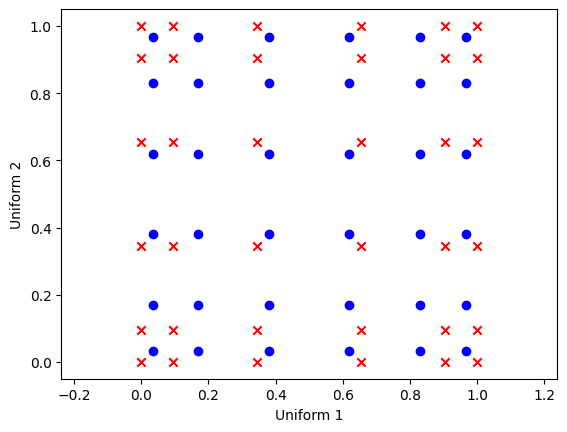

In [15]:
# example quadrature
u1 = cp.Uniform(0,1)
u2 = cp.Uniform(0,1)
joint_distribution = cp.J(u1, u2)

order = 5


nodes_gaussian, weights_gaussian = cp.generate_quadrature(
    order=order,
    dist=joint_distribution,
    rule="G",
)

nodes_clenshaw, weights_clenshaw = cp.generate_quadrature(
    order=order,
    dist=joint_distribution,
    rule="C",
)


print('Number of nodes gaussian quadrature: {}'.format(len(nodes_gaussian[0])))
print('Number of nodes clenshaw-curtis quadrature: {}'.format(len(nodes_clenshaw[1])))


fig1, ax1 = plt.subplots()
ax1.scatter(*nodes_gaussian, marker='o', color='b')
ax1.scatter(*nodes_clenshaw, marker= 'x', color='r')
ax1.set_xlabel("Uniform 1")
ax1.set_ylabel("Uniform 2")
ax1.axis('equal')

In the following all quadrature rules implemented in chaospy are highlighted:

<table class="dotable" border="1">
<thead>
<tr><th align="center"> Collection of quadrature rules</th> <th align="center">   Name  </th> <th align="center">Key</th> </tr>
</thead>
<tbody>
<tr><td align="center">   Optimal Gaussian quadrature        </td> <td align="center">   Gaussian     </td> <td align="center">   G      </td> </tr>
<tr><td align="center">   Gauss-Legendre quadrature          </td> <td align="center">   Legendre     </td> <td align="center">   E      </td> </tr>
<tr><td align="center">   Clenshaw-Curtis quadrature         </td> <td align="center">   Clenshaw     </td> <td align="center">   C      </td> </tr>
<tr><td align="center">   Leja quadrature                    </td> <td align="center">   Leja         </td> <td align="center">   J      </td> </tr>
<tr><td align="center">   Hermite Genz-Keizter 16 rule       </td> <td align="center">   Genz         </td> <td align="center">   Z      </td> </tr>
<tr><td align="center">   Gauss-Patterson quadrature rule    </td> <td align="center">   Patterson    </td> <td align="center">   P      </td> </tr>
</tbody>
</table>

It is also possible to use sparse grid quadrature. For this purpose Clenshaw-Curtis method is advised since it is nested.

In the following example we show sparse vs. normal quadrature nodes:

Number of nodes normal clenshaw-curtis quadrature: 9
Number of nodes clenshaw-curtis quadrature with sparse grid : 13


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

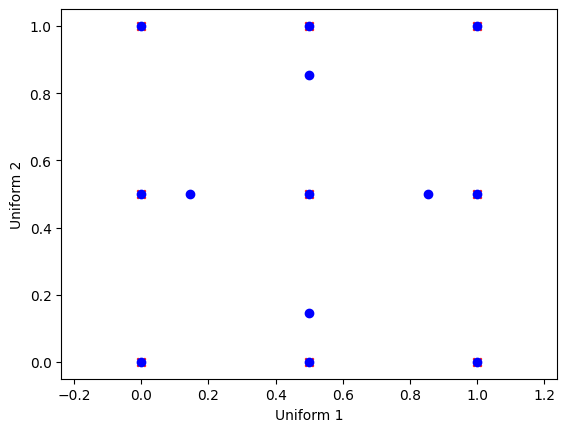

In [16]:
# example sparse grid quadrature
u1 = cp.Uniform(0,1)
u2 = cp.Uniform(0,1)
joint_distribution = cp.J(u1, u2)

order = 2
# sparse grid has exponential growth, thus a smaller order results in more points
nodes_clenshaw, weights_clenshaw = cp.generate_quadrature(
    order=order, dist=joint_distribution, rule="C"
)
nodes_clenshaw_sparse, weights_clenshaw_sparse = cp.generate_quadrature(
    order=order, dist=joint_distribution, rule="C", sparse=True
)


print('Number of nodes normal clenshaw-curtis quadrature: {}'.format(len(nodes_clenshaw[0])))
print('Number of nodes clenshaw-curtis quadrature with sparse grid : {}'.format(len(nodes_clenshaw_sparse[0])))

fig1, ax1 = plt.subplots()
ax1.scatter(*nodes_clenshaw, marker= 'x', color='r')
ax1.scatter(*nodes_clenshaw_sparse, marker= 'o', color='b')
ax1.set_xlabel("Uniform 1")
ax1.set_ylabel("Uniform 2")
ax1.axis('equal')

#### Compute the polynomial Chaos Expansion

After the model is evaluated for all integration nodes, the polynomial chaos expansion can be generated with the following method:

In [17]:
# spectral projection in chaospy
cp.fit_quadrature?

In the following we show again a complete example for polynomial chaos expansion using the pseudo spectral approach to calculate the
expansion coefficients.
The model applied the same simple mathematical expression as before:

<!-- Equation labels as ordinary links -->
<div id="eq:dummy_model_repeat"></div>

$$
\begin{equation}
 y(z_1, z_2) = z_1 + z_1 z_2
\label{eq:dummy_model_repeat} \tag{3}
\end{equation}
$$

The random variables for $Z_1, Z_2$ are defined as simple uniform random variables:

<!-- Equation labels as ordinary links -->
<div id="eq:dummy_rv_repeat"></div>

$$
\begin{equation}
Z_1 = \mbox{U}(0,1), \quad Z_2 = \mbox{U}(0,1)
\label{eq:dummy_rv_repeat} \tag{4}
\end{equation}
$$

In [18]:
# example spectral projection
# 1. define marginal and joint distributions
u1 = cp.Uniform(0,1)
u2 = cp.Uniform(0,1)
joint_distribution = cp.J(u1, u2)

# 2. generate orthogonal polynomials
polynomial_order = 3
poly = cp.expansion.stieltjes(polynomial_order, joint_distribution)

# 4.1 generate quadrature nodes and weights
order = 5
nodes, weights = cp.generate_quadrature(
    order=order,
    dist=joint_distribution,   # <-- was: domain=joint_distribution
    rule="G"                   # gaussian quadrature (can also use "C", "E", etc.)
)


# 4.2 evaluate the simple model for all nodes
model_evaluations = nodes[0]+nodes[1]*nodes[0]

# 4.3 use quadrature to generate the polynomial chaos expansion
gpce_quadrature = cp.fit_quadrature(poly, nodes, weights, model_evaluations)
print("Success")

Success


### Post-processing in Chaospy
<span id="sec:statistical_analysis"></span>

Once the polynomial chaos expansion is created either with **pseudo-spectral projection** or with **regression** method
The calculation of statistics is straight forward.
The following listing gives an overview of all available methods take all the same input parameter the **polynomial-expansion** and
the **joint-distribution** (see also example below).

Note, that one can also calculate uncertainty statistics on distributions only as well.

#### Uncertainty quantification

* Expected value: `cp.E`

* Variance: `cp.Var`

* Standard deviation: `cp.Std`

* Curtosis: `cp.Kurt`

* Skewness: `cp.Skew`

* Distribution of Y: `cp.QoI_Dist`

* Prediction intervals: `cp.Perc`, which is a method to calculate percentiles: an additional argument defining the percentiles needs to be passed.

If multiple quantities of interest are available:

* Covariance matrix: `cp.Cov`

* Correlation matrix: `cp.Corr`

* Spearman correlation: `cp.Spearman`

* Auto-correlation function: `cp.Acf`

In [19]:
# example uq
# Expected value
exp_reg = cp.E(gpce_regression, joint_distribution)
exp_ps  = cp.E(gpce_quadrature,  joint_distribution)

# Standard deviation
std_reg = cp.Std(gpce_regression, joint_distribution)
std_ps  = cp.Std(gpce_quadrature,  joint_distribution)

# Prediction intervals (90%)
pred_reg = cp.Perc(gpce_regression, [5, 95], joint_distribution)
pred_ps  = cp.Perc(gpce_quadrature,  [5, 95], joint_distribution)

# Assemble table
df_stats = pd.DataFrame(
    {
        "E (regression)": [f"{exp_reg:.3f}"],
        "E (projection)": [f"{exp_ps:.3f}"],
        "Std (regression)": [f"{std_reg:.3f}"],
        "Std (projection)": [f"{std_ps:.3f}"],
        "PI 5–95% (regression)": [f"[{pred_reg[0]:.3f}, {pred_reg[1]:.3f}]"],
        "PI 5–95% (projection)": [f"[{pred_ps[0]:.3f}, {pred_ps[1]:.3f}]"],
    },
    index=["Y"]
)

display(section_title("Uncertainty statistics from PCE"))
pretty_table(df_stats)

,E (regression),E (projection),Std (regression),Std (projection),PI 5–95% (regression),PI 5–95% (projection)
Y,0.750,0.750,0.464,0.464,"[0.077, 1.576]","[0.070, 1.575]"


#### Sensitivity analysis

The variance bases sensitivity indices can be calculated directly from the expansion.
The `chaospy` package provides the following methods:

* first order indices: `cp.Sens_m`

* second order indices: `cp.Sens_m2`

* total indices: `cp.Sens_t`

Here is an example for the first and total indices for both expansions:

In [20]:
# example sens
sensFirst_reg = cp.Sens_m(gpce_regression, joint_distribution)
sensFirst_ps = cp.Sens_m(gpce_quadrature, joint_distribution)

sensT_reg = cp.Sens_t(gpce_regression, joint_distribution)
sensT_ps = cp.Sens_t(gpce_quadrature, joint_distribution)


# Assemble table
df_sens = pd.DataFrame(
    {
        "S (regression)": sensFirst_reg,
        "S (projection)": sensFirst_ps,
        "ST (regression)": sensT_reg,
        "ST (projection)": sensT_ps,
    },
    index=[f"X{i+1}" for i in range(len(sensFirst_reg))]
).round(3)

display(section_title("Sensitivity indices from PCE"))
pretty_table(df_sens)

,S (regression),S (projection),ST (regression),ST (projection)
X1,0.871,0.871,0.903,0.903
X2,0.097,0.097,0.129,0.129


# Take away

 - PCE = surrogate model in probability space.  
 - PDFs determine the polynomial basis.  
 - Regression and projection are two ways to build the expansion.  
 - Statistics and Sobol indices come directly from the PCE.  
 - Chaospy supports the complete workflow.

# References

1. <span id="feinberg_2015"></span> **J. Feinberg and H. P. Langtangen**.  Chaospy: an Open Source Tool for Designing Methods of Uncertainty Quantification, *Journal of Computational Science*, 11, pp. 46-57, 2015.